In [4]:
import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import xarray as xr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats

# KD490

In [8]:
file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/*.nc'))
all_ds = xr.open_mfdataset(file_list, concat_dim='time', combine='nested')
## combine all the files into one, massive DataSet so that we can do comparisons over years
all_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    KD490      (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [3]:
weekly = all_ds['KD490'].resample(time='1W').mean()
monthly_kd490 = all_ds['KD490'].resample(time='1ME').mean()
seasonal_kd490 = all_ds['KD490'].resample(time='QS-DEC').mean()
seasonal_kd490['season'] = seasonal_kd490['time'].dt.season


In [4]:
stat_trend_ds = xr.open_dataset('KD490_trend_with_stats.nc') ## this is weekly trends

In [5]:
significant = stat_trend_ds['pvalue'] < 0.05  # 95% confidence
trend_sig = stat_trend_ds['slope'].where(significant)

In [6]:
seasonal_ds = xr.open_dataset('KD490_seasonal_trends.nc')

In [7]:
significant_w_seasons = seasonal_ds['pvalue'] < 0.05  # 95% confidence
trend_sig_seasons = seasonal_ds['slope'].where(significant_w_seasons)

# Chlorophyll

In [8]:
chla_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/chlorophyll/*.nc'))
chla_ds = xr.open_mfdataset(chla_file_list, concat_dim='time', combine='nested')
chla_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CHL        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    institution:               ACRI
    comment:                   average
    contact:                   servicedesk.cmems@acri-st.fr
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-plankton_my_l3-multi-1km_P1D
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

In [9]:
weekly_chla = chla_ds['CHL'].resample(time='1W').mean()
monthly_chla = chla_ds['CHL'].resample(time='1ME').mean()
seasonal_chla = chla_ds['CHL'].resample(time='QS-DEC').mean()
seasonal_chla['season'] = seasonal_chla['time'].dt.season

In [10]:
weekly_trend_chla = xr.open_dataset('Chl_a_trend_with_stats.nc')

In [11]:
w_significant_chla = weekly_trend_chla['pvalue'] < 0.05  # 95% confidence
w_trend_sig_chla = weekly_trend_chla['slope'].where(w_significant_chla)

In [12]:
seasonal_trend_chla = xr.open_dataset('Chl_a_seasonal_trends.nc')

In [13]:
sea_significant_chla = seasonal_trend_chla['pvalue'] < 0.05  # 95% confidence
sea_trend_sig_chla =seasonal_trend_chla['slope'].where(sea_significant_chla)

# CDOM

In [14]:
cdom_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/CDOM/*.nc'))
cdom_ds = xr.open_mfdataset(cdom_file_list, concat_dim='time', combine='nested')
display(cdom_ds)

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CDM        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-optics_my_l3-multi-1km_P1D
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

In [15]:
weekly_cdom = cdom_ds['CDM'].resample(time='1W').mean( skipna=True)
monthly_cdom = cdom_ds['CDM'].resample(time='1ME').mean( skipna=True)
seasonal_cdom = cdom_ds['CDM'].resample(time='QS-DEC').mean(skipna=True)
seasonal_cdom['season'] = seasonal_cdom['time'].dt.season

In [16]:
weekly_trend_cdom = xr.open_dataset('CDOM_trend_with_stats.nc')

In [17]:
w_significant_cdom = weekly_trend_cdom['pvalue'] < 0.05  # 95% confidence
w_trend_sig_cdom = weekly_trend_cdom['slope'].where(w_significant_cdom)

In [18]:
seasonal_trend_cdom = xr.open_dataset('CDOM_seasonal_trends.nc')

In [19]:
sea_significant_cdom = seasonal_trend_cdom['pvalue'] < 0.05  # 95% confidence
sea_trend_sig_cdom = seasonal_trend_cdom['slope'].where(sea_significant_cdom)

# SPM

In [20]:
spm_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/SPM/*.nc'))
spm_ds = xr.open_mfdataset(spm_file_list, concat_dim='time', combine='nested')
display(spm_ds)

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    SPM        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    comment:                   average
    source:                    surface observation
    Conventions:               CF-1.8, ACDD-1.3
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    history:                   Created using software developed at ACRI-ST
    institution:               ACRI
    copernicusmarine_version:  2.2.2

In [21]:
weekly_spm = spm_ds['SPM'].resample(time='1W').mean(skipna=True)
monthly_spm = spm_ds['SPM'].resample(time='1ME').mean(skipna=True)
seasonal_spm = spm_ds['SPM'].resample(time='QS-DEC').mean(skipna=True)
seasonal_spm['season'] = seasonal_spm['time'].dt.season

weekly_trend_spm = xr.open_dataset('SPM_trend_with_stats.nc')

w_significant_spm = weekly_trend_spm['pvalue'] < 0.05  # 95% confidence
w_trend_sig_spm = weekly_trend_spm['slope'].where(w_significant_spm)

seasonal_trend_spm = xr.open_dataset('SPM_seasonal_trends.nc')

sea_significant_spm = seasonal_trend_spm['pvalue'] < 0.05  # 95% confidence
sea_trend_sig_spm = seasonal_trend_spm['slope'].where(sea_significant_spm)

# Analysis
- Which correlates with KD490 more: Chl, CDOM, or SPM?
- When is the spring bloom occuring, and is it happening sooner and for longer?
- How is temperature playing a role?

## Medians, Means, and General Line Up of Components

In [22]:
## looking at medians and means over months and years of the three variables to see what aligns

## medians
chla_year_median = chla_ds['CHL'].quantile(0.5,dim=['latitude','longitude']).groupby('time.year').quantile(0.5, dim='time')

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


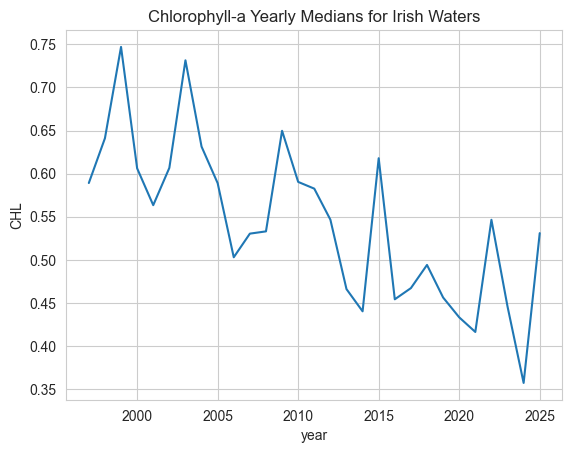

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [23]:
chla_year_median.plot()
plt.title('Chlorophyll-a Yearly Medians for Irish Waters')
plt.show()

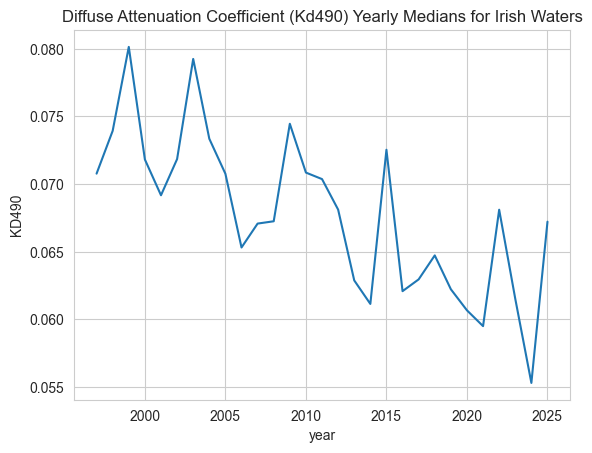

In [24]:
kd490_year_median = all_ds['KD490'].quantile(0.5, dim=['latitude', 'longitude']).groupby('time.year').quantile(0.5,dim='time')

kd490_year_median.plot()
plt.title('Diffuse Attenuation Coefficient (Kd490) Yearly Medians for Irish Waters')
plt.show()

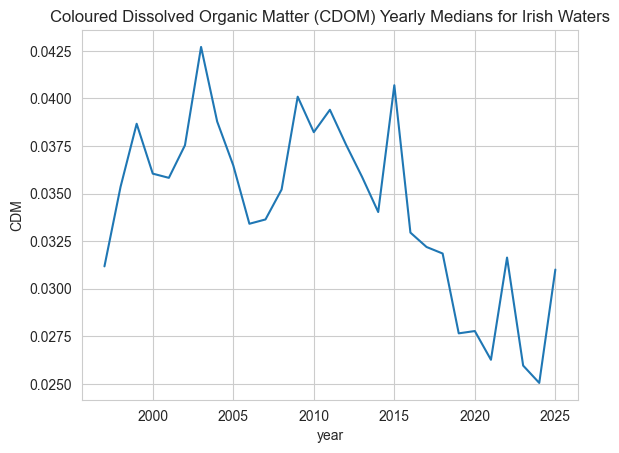

In [25]:
cdom_year_median = cdom_ds['CDM'].quantile(0.5, dim=['latitude', 'longitude']).groupby('time.year').quantile(0.5,dim='time')

cdom_year_median.plot()
plt.title('Coloured Dissolved Organic Matter (CDOM) Yearly Medians for Irish Waters')
plt.show()

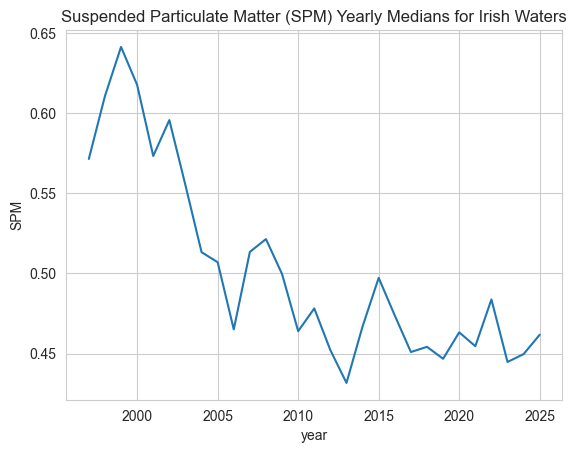

In [26]:
spm_year_median = spm_ds['SPM'].quantile(0.5, dim=['latitude', 'longitude']).groupby('time.year').quantile(0.5,dim='time')
spm_year_median.plot()
plt.title('Suspended Particulate Matter (SPM) Yearly Medians for Irish Waters')
plt.show()

## Means

In [27]:

chla_year_mean = chla_ds['CHL'].mean(dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')

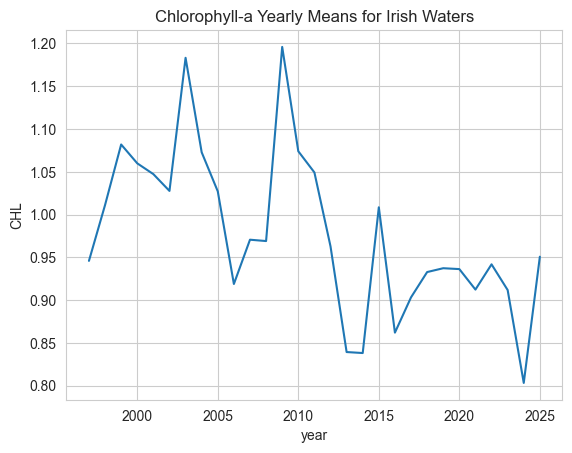

In [28]:
chla_year_mean.plot()
plt.title('Chlorophyll-a Yearly Means for Irish Waters')
plt.show()

In [29]:
chla_month_mean = chla_ds['CHL'].mean(dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')

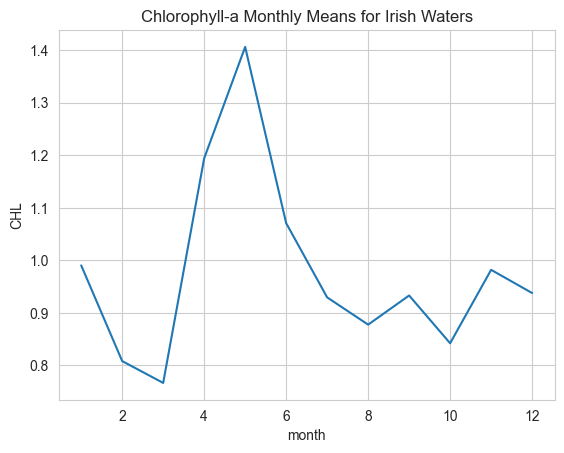

In [30]:
chla_month_mean.plot()
plt.title('Chlorophyll-a Monthly Means for Irish Waters')
plt.show()

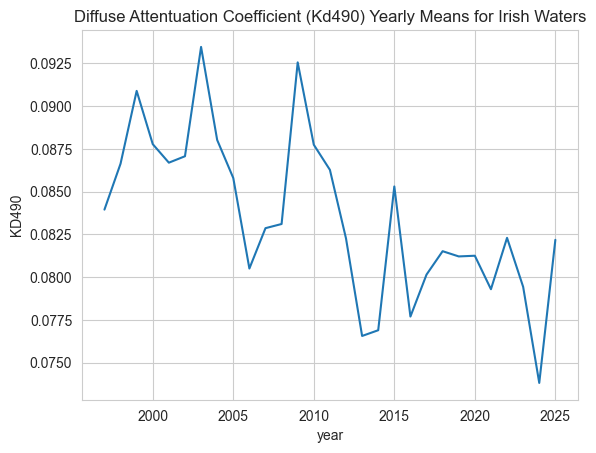

In [31]:
kd490_year_mean = all_ds['KD490'].mean(dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')
kd490_year_mean.plot()
plt.title('Diffuse Attentuation Coefficient (Kd490) Yearly Means for Irish Waters')
plt.show()

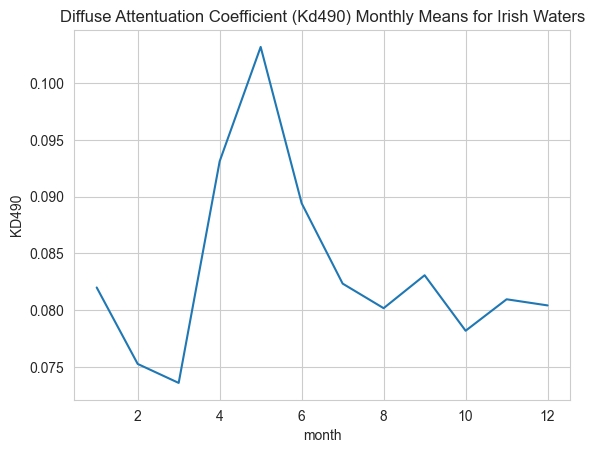

In [32]:
kd490_month_mean = all_ds['KD490'].mean(dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')
kd490_month_mean.plot()
plt.title('Diffuse Attentuation Coefficient (Kd490) Monthly Means for Irish Waters')
plt.show()

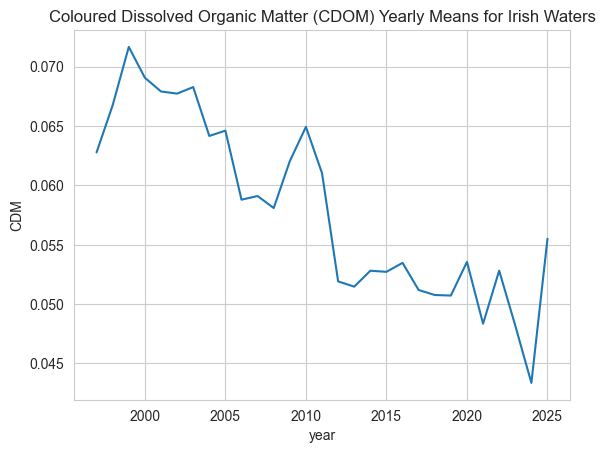

In [33]:
cdom_year_mean = cdom_ds['CDM'].mean(dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')
cdom_year_mean.plot()
plt.title('Coloured Dissolved Organic Matter (CDOM) Yearly Means for Irish Waters')
plt.show()

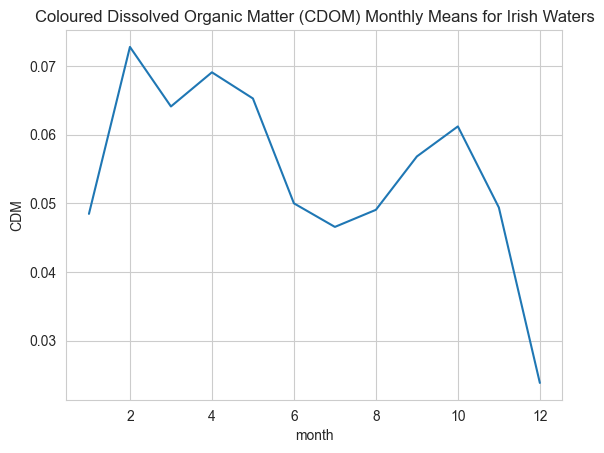

In [34]:
cdom_month_mean = cdom_ds['CDM'].mean(dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')
cdom_month_mean.plot()
plt.title('Coloured Dissolved Organic Matter (CDOM) Monthly Means for Irish Waters')
plt.show()

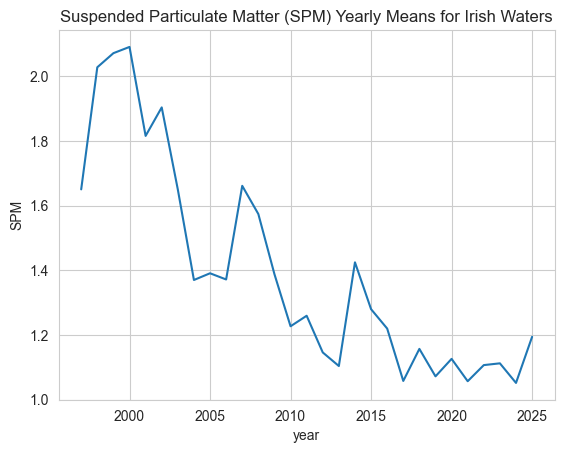

In [35]:
spm_year_mean = spm_ds['SPM'].mean( dim=['latitude', 'longitude']).groupby('time.year').mean(dim='time')
spm_year_mean.plot()
plt.title('Suspended Particulate Matter (SPM) Yearly Means for Irish Waters')
plt.show()

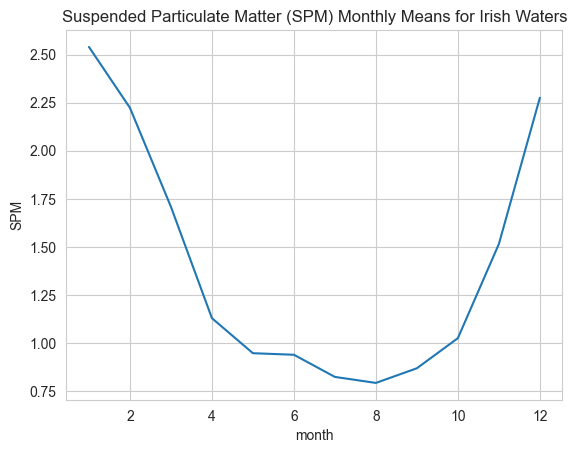

In [36]:
spm_month_mean = spm_ds['SPM'].mean( dim=['latitude', 'longitude']).groupby('time.month').mean(dim='time')
spm_month_mean.plot()
plt.title('Suspended Particulate Matter (SPM) Monthly Means for Irish Waters')
plt.show()

**looking at the monthly mean over the years, so it will be monthly values but for the whole time series**

In [37]:

monthly_chla_mean = monthly_chla.mean(dim=['latitude', 'longitude'], skipna=True)
monthly_kd490_mean = monthly_kd490.mean(dim=['latitude', 'longitude'], skipna=True)
monthly_cdom_mean = monthly_cdom.mean(dim=['latitude', 'longitude'], skipna=True)
monthly_spm_mean = monthly_spm.mean(dim=['latitude', 'longitude'], skipna=True)

In [38]:

chla_m = monthly_chla_mean
kd_m = monthly_kd490_mean
cdom_m = monthly_cdom_mean
spm_m  = monthly_spm_mean

Text(0, 0.5, 'Value')

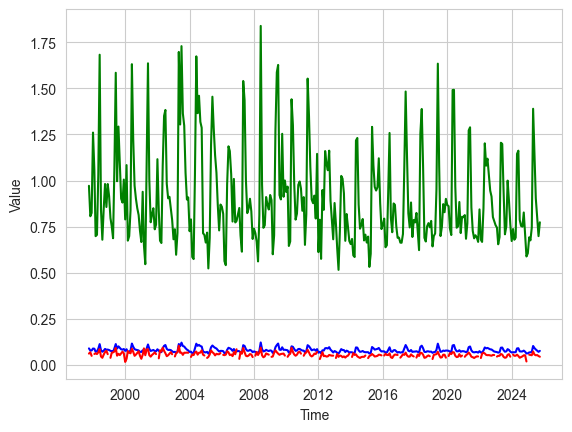

In [69]:
## can skip remaking this plot with SPM
plt.plot(kd_m['time'], kd_m, label='KD490', color='blue')
plt.plot(cdom_m['time'], cdom_m, label='CDM', color='red')
plt.plot(chla_m['time'], chla_m, label='CHL', color='green')
plt.xlabel('Time')
plt.ylabel('Value')

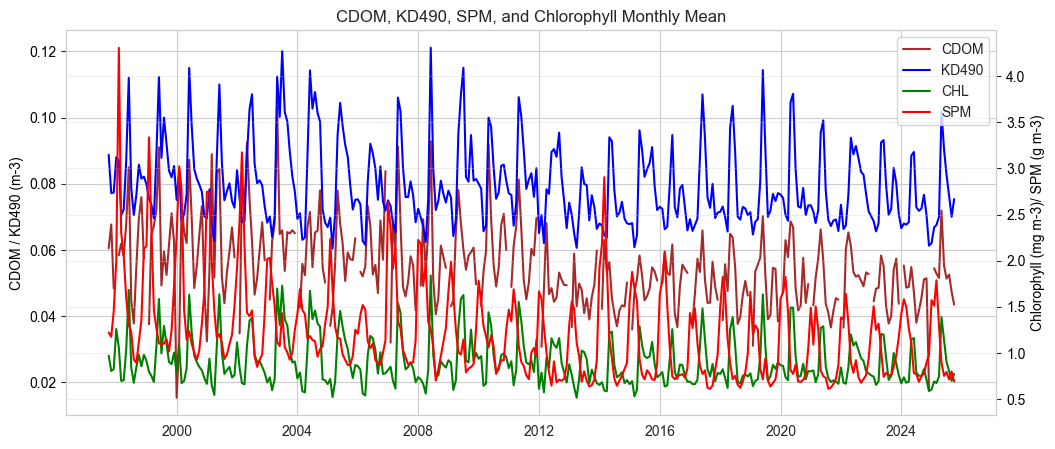

In [39]:
fig, ax1 = plt.subplots(figsize=(12,5))

# Plot CDOM and KD490 on left axis
ax1.plot(cdom_m['time'], cdom_m, color='brown', label='CDOM')
ax1.plot(kd_m['time'], kd_m, color='blue', label='KD490')
ax1.set_ylabel('CDOM / KD490 (m-3)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Plot Chlorophyll on right axis
ax2 = ax1.twinx()
ax2.plot(chla_m['time'], chla_m, color='green', label='CHL')
ax2.plot(spm_m['time'], spm_m, color='red', label='SPM')
ax2.set_ylabel('Chlorophyll (mg m-3)/ SPM (g m-3)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('CDOM, KD490, SPM, and Chlorophyll Monthly Mean')
plt.grid(alpha=0.3)
plt.show()


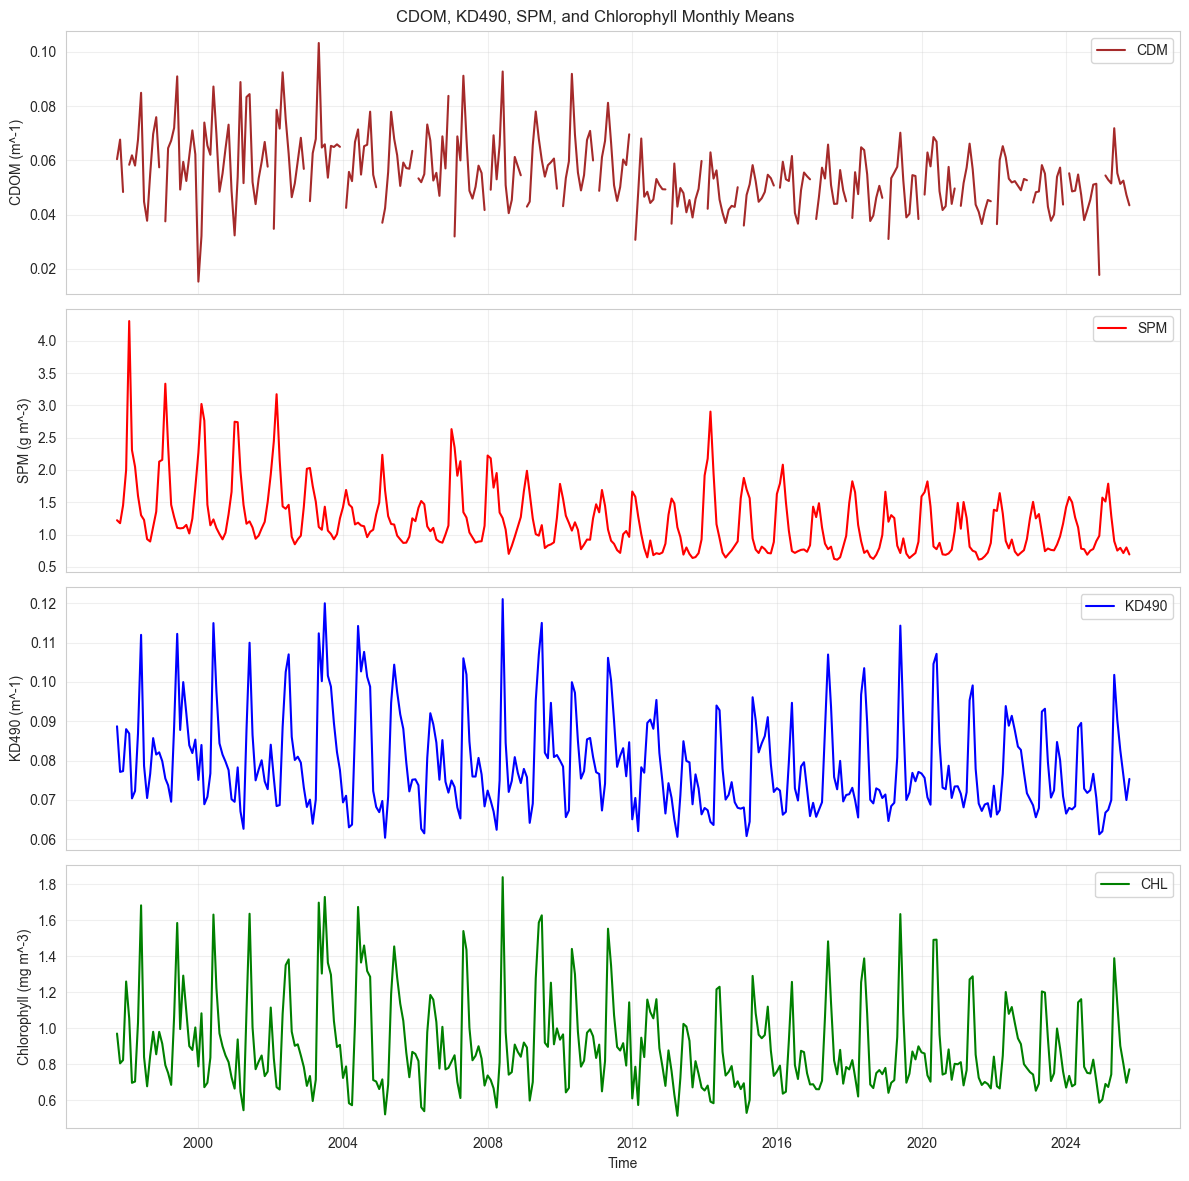

In [43]:
fig, axes = plt.subplots(4,1,figsize=(12,12), sharex=True)

## cdom
axes[0].plot(cdom_m['time'], cdom_m, color='brown', label='CDM')
axes[0].set_ylabel('CDOM (m^-1)')
axes[0].legend()
axes[0].grid(alpha=0.3)

## spm
axes[1].plot(spm_m['time'], spm_m, color='red', label='SPM')
axes[1].set_ylabel('SPM (g m^-3)')
axes[1].legend()
axes[1].grid(alpha=0.3)

## kd490
axes[2].plot(kd_m['time'], kd_m, color='blue', label='KD490')
axes[2].set_ylabel('KD490 (m^-1)')
axes[2].legend()
axes[2].grid(alpha=0.3)

## chl
axes[3].plot(chla_m['time'], chla_m, color='green', label='CHL')
axes[3].set_ylabel('Chlorophyll (mg m^-3)')
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[3].set_xlabel('Time')


plt.suptitle('CDOM, KD490, SPM, and Chlorophyll Monthly Means')
plt.tight_layout()
fig.savefig('CDOM_KD490_Chla_SPM_TimeSeries_monthlymean.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
## need to go back and add skipna=True and min_count=1 to the monthly resampling and the mean functions - CDOM missing months of data
## i did this and nothing really changed on the CDOM map

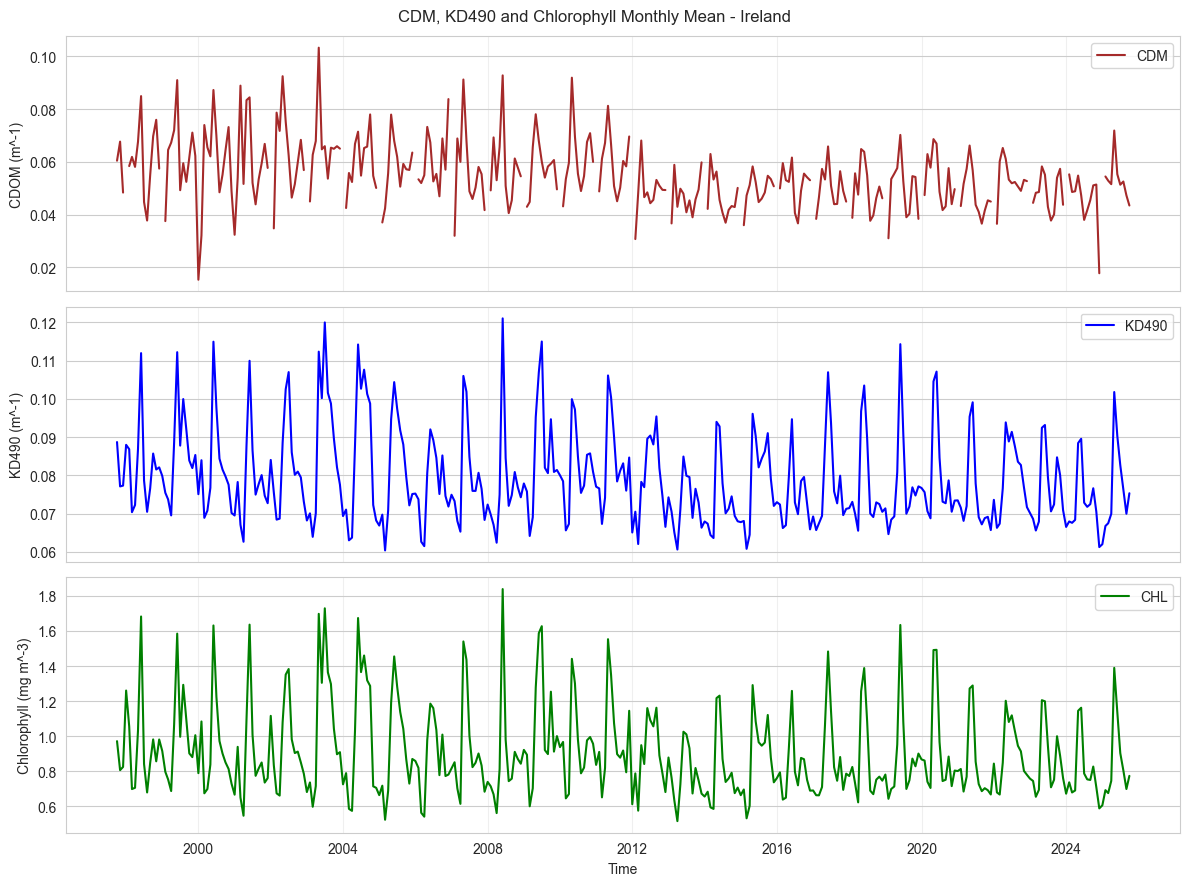

In [80]:
## don't need to alter this for SPM, only change was for the grid and it didn't do what I wanted anyways
fig, axes = plt.subplots(3,1,figsize=(12,9), sharex=True)

## cdom
axes[0].plot(cdom_m['time'], cdom_m, color='brown', label='CDM')
axes[0].set_ylabel('CDOM (m^-1)')
axes[0].legend()
axes[0].grid(alpha=0.3, which='both',axis='x')

## kd490
axes[1].plot(kd_m['time'], kd_m, color='blue', label='KD490')
axes[1].set_ylabel('KD490 (m^-1)')
axes[1].legend()
axes[1].grid(alpha=0.3,which='both',axis='x')

## chl
axes[2].plot(chla_m['time'], chla_m, color='green', label='CHL')
axes[2].set_ylabel('Chlorophyll (mg m^-3)')
axes[2].legend()
axes[2].grid(alpha=0.3,which='both',axis='x')

axes[2].set_xlabel('Time')

plt.suptitle('CDM, KD490 and Chlorophyll Monthly Mean - Ireland')
plt.tight_layout()
fig.savefig('CDOM_KD490_Chla_TimeSeries_monthlymean.png')
plt.show()

## What days had the highest CDOM Concentrations in West Coast Ireland?

In [18]:
max_cdom_sorted = cdom_ds.sortby(cdom_ds['CDM'].max(dim=('latitude','longitude')), ascending=False)
max_cdom_sorted

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 2025-01-23 2025-01-21 ... 2024-01-28
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CDM        (time, latitude, longitude) float32 54GB dask.array<chunksize=(352, 1056, 1248), meta=np.ndarray>
Attributes:
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-optics_my_l3-multi-1km_P1D
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

In [22]:
max_cdom_sorted['time'].isel(time=slice(0,50))

<xarray.DataArray 'time' (time: 50)> Size: 400B
array(['2025-01-23T00:00:00.000000000', '2025-01-21T00:00:00.000000000',
       '2025-01-19T00:00:00.000000000', '2025-01-18T00:00:00.000000000',
       '2025-01-17T00:00:00.000000000', '2025-01-16T00:00:00.000000000',
       '2025-01-14T00:00:00.000000000', '2025-01-13T00:00:00.000000000',
       '2025-01-12T00:00:00.000000000', '2025-01-11T00:00:00.000000000',
       '2025-01-10T00:00:00.000000000', '2025-01-09T00:00:00.000000000',
       '2025-01-08T00:00:00.000000000', '2025-01-07T00:00:00.000000000',
       '2025-01-06T00:00:00.000000000', '2025-01-05T00:00:00.000000000',
       '2025-01-04T00:00:00.000000000', '2025-01-03T00:00:00.000000000',
       '2025-01-02T00:00:00.000000000', '2025-01-01T00:00:00.000000000',
       '2024-12-31T00:00:00.000000000', '2024-12-30T00:00:00.000000000',
       '2024-12-29T00:00:00.000000000', '2024-12-28T00:00:00.000000000',
       '2024-12-27T00:00:00.000000000', '2024-12-26T00:00:00.000000000',
       '2024-12-25T00:00:00.000000000', '2024-12-24T00:00:00.000000000',
       '2024-12-23T00:00:00.000000000', '2024-12-22T00:00:00.000000000',
       '2024-12-21T00:00:00.000000000', '2024-12-20T00:00:00.000000000',
       '2024-12-19T00:00:00.000000000', '2024-12-18T00:00:00.000000000',
       '2024-12-17T00:00:00.000000000', '2024-12-16T00:00:00.000000000',
       '2024-12-15T00:00:00.000000000', '2024-12-14T00:00:00.000000000',
       '2024-12-13T00:00:00.000000000', '2024-12-12T00:00:00.000000000',
       '2024-12-11T00:00:00.000000000', '2024-12-10T00:00:00.000000000',
       '2024-12-09T00:00:00.000000000', '2024-12-08T00:00:00.000000000',
       '2024-12-07T00:00:00.000000000', '2024-12-06T00:00:00.000000000',
       '2024-12-05T00:00:00.000000000', '2024-12-04T00:00:00.000000000',
       '2024-12-03T00:00:00.000000000', '2024-12-02T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 400B 2025-01-23 2025-01-21 ... 2024-12-02
Attributes:
    axis:           T
    unit_long:      Days Since 1900-01-01
    long_name:      Time
    standard_name:  time

**In the block shown above, we can see that the highest values all appear in 2025, then 2024. But this is the whole lat/long range, which includes the Irish and Celtic Seas. What about just west coast ireland?**

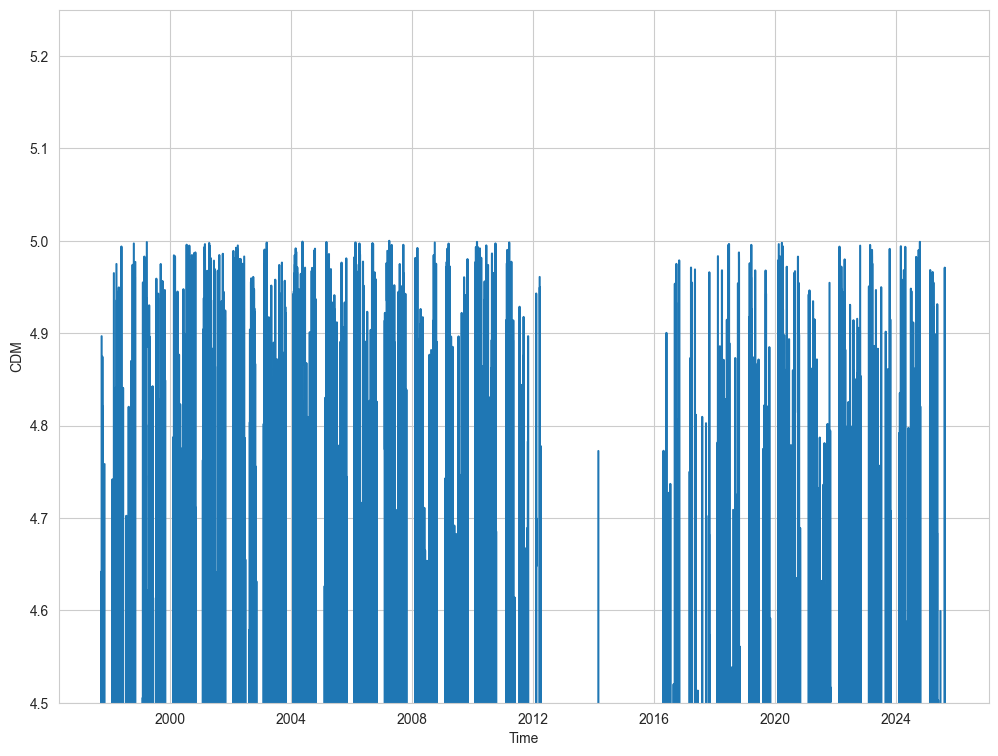

In [37]:
plt.figure(figsize=(12,9))
cdom_ds['CDM'].sel(latitude=slice(51.25,55.5),longitude=slice(-11,-7)).max(dim=('latitude','longitude')).plot()
plt.ylim(4.5,5.25)
plt.show()

In [55]:
west_cdom_ds = cdom_ds.sel(latitude=slice(51.25,55.5),longitude=slice(-11,-6.5))
west_max_cdom_sorted = west_cdom_ds.sortby(west_cdom_ds['CDM'].max(dim=('latitude','longitude')), ascending=False)

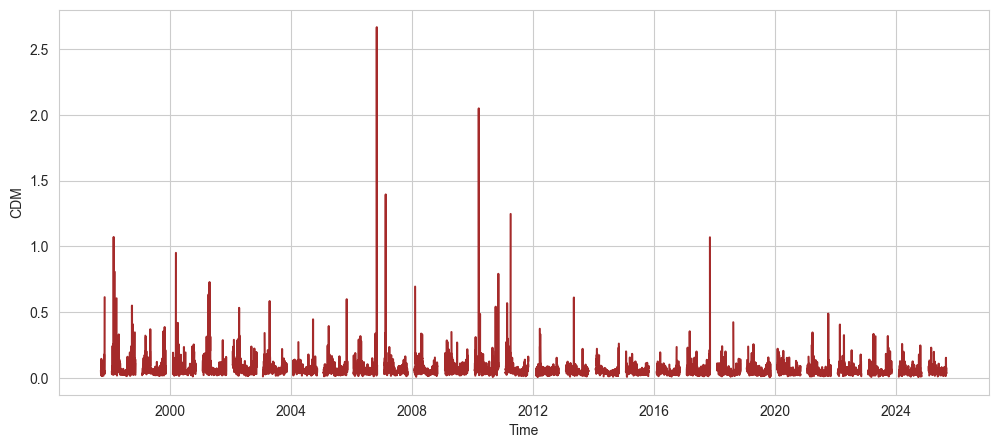

In [47]:
plt.figure(figsize=(12,5))
west_cdom_ds['CDM'].mean(dim=('latitude','longitude')).plot(color='brown')
plt.show()

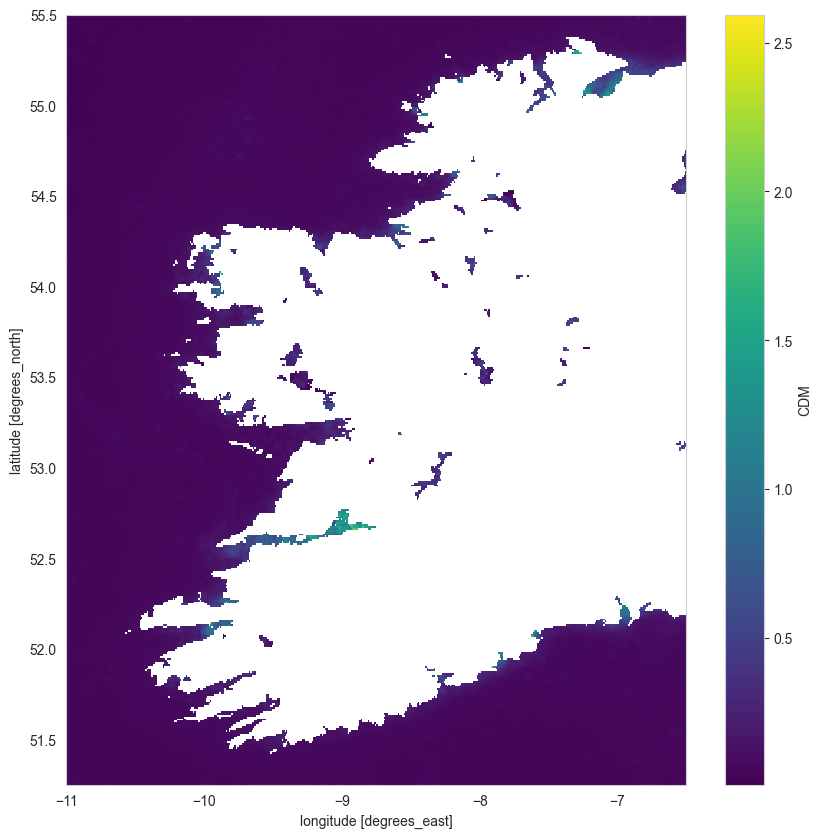

In [56]:
plt.figure(figsize=(10,10))
west_cdom_ds['CDM'].sel(latitude=slice(51.25,55.5),longitude=slice(-11,-6), time=slice('9-4-2024','9-4-2025')).mean(dim=('time')).plot()
plt.show()

## Dates of Spring Bloom

In [58]:
chla_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    CHL        (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    institution:               ACRI
    comment:                   average
    contact:                   servicedesk.cmems@acri-st.fr
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    Conventions:               CF-1.8, ACDD-1.3
    title:                     cmems_obs-oc_atl_bgc-plankton_my_l3-multi-1km_P1D
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.2

# Kd490 and Secchi Depths Comparison

Current Idea: Take the Latitude, Longitude, and Dates that I have for valid Secchi Data for Coastal Ireland, and pull those numbers from Kd490 data, see what I get
secchi_right.csv comes from the Secchi_Depths.ipynb notebook analysis from ICES data.

In [9]:
secchi = pd.read_csv('/Users/25298423/PycharmProjects/JupyterProject1/secchi_right.csv')
secchi

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022
...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982200,-6.032500,4.0,0.90,2014
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982200,-6.032500,3.0,1.50,2014
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982200,-6.032500,4.0,3.20,2014
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346200,-6.470200,6.0,0.40,2014


In [10]:
all_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    KD490      (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [11]:
secchi.rename(columns={'latitude_degN':'latitude','longitude_degE':'longitude'}, inplace=True)
secchi.dtypes

cruise              int64
station            object
time               object
latitude          float64
longitude         float64
bottom_depth_m    float64
secchi_depth_m    float64
year                int64
dtype: object

In [12]:
secchi['latitude'] = secchi['latitude'].astype('float32')
secchi['longitude'] = secchi['longitude'].astype('float32')
secchi['time'] = pd.to_datetime(secchi['time'], utc=True)

In [13]:
kd_daily = all_ds['KD490'].sel(
    time= xr.DataArray(secchi['time'], dims='points'),
    method='nearest'
)

In [14]:
kd_interp = kd_daily.interp(
    latitude=('points', secchi['latitude']),
    longitude=('points', secchi['longitude'])
)

nan_mask = kd_interp.isnull()

nan_points = nan_mask.compute().values

if nan_points.any():

    kd_fallback = kd_daily.sel(
        latitude = xr.DataArray(secchi['latitude'][nan_points], dims='points'),
        longitude = xr.DataArray(secchi['longitude'][nan_points], dims='points'),
        method='nearest'
    )

    kd_interp = kd_interp.where(~nan_mask, kd_fallback)

secchi['Kd490_match'] = kd_interp.compute().to_pandas()

In [15]:
secchi['date'] = secchi['time'].dt.date
secchi['date'] = pd.to_datetime(secchi['date'], utc=True)

In [16]:
secchi.dtypes

cruise                          int64
station                        object
time              datetime64[ns, UTC]
latitude                      float32
longitude                     float32
bottom_depth_m                float64
secchi_depth_m                float64
year                            int64
date              datetime64[ns, UTC]
dtype: object

In [17]:
xr.DataArray(secchi['date'], dims='points')

<xarray.DataArray 'date' (points: 19544)> Size: 156kB
array(['2022-03-02T00:00:00.000000000', '2023-02-02T00:00:00.000000000',
       '2022-05-16T00:00:00.000000000', ...,
       '2014-07-31T00:00:00.000000000', '2014-05-19T00:00:00.000000000',
       '2014-08-18T00:00:00.000000000'],
      shape=(19544,), dtype='datetime64[ns]')
Coordinates:
  * points   (points) int64 156kB 0 1 2 3 4 5 ... 19539 19540 19541 19542 19543

In [18]:
kd_match = all_ds['KD490'].sel(
    time = xr.DataArray(secchi['date'], dims='points'),
    latitude = xr.DataArray(secchi['latitude'], dims='points'),
    longitude = xr.DataArray(secchi['longitude'], dims='points'),
    method='nearest'
)

In [19]:

# Compute lat/lon differences
lat_diff = np.abs(kd_match['latitude'].values - secchi['latitude'].values)
lon_diff = np.abs(kd_match['longitude'].values - secchi['longitude'].values)

# Mask for distance <= 0.2° and exact date match
time_diff = np.abs(kd_match['time'].values - secchi['date'].values)
mask = (lat_diff <= 0.005) & (lon_diff <= 0.005) & (time_diff == np.timedelta64(0, 'D'))

# Apply mask
kd_match_filtered = kd_match.where(mask, drop=False)

In [20]:
secchi['Kd490_lat'] = kd_match_filtered['latitude'].values
secchi['Kd490_lon'] = kd_match_filtered['longitude'].values
secchi['Kd490_date'] = kd_match_filtered['time'].values


In [21]:
secchi['Kd490_match'] = kd_match_filtered.compute().to_pandas()

In [22]:
secchi_valid = secchi.dropna(subset=['Kd490_match'])
secchi_valid

,cruise,station,time,latitude,longitude,bottom_depth_m,secchi_depth_m,year,date,Kd490_lat,Kd490_lon,Kd490_date,Kd490_match
26,411,101251-1,2022-03-03 14:52:00+00:00,51.912373,-7.83898,8.3,0.75,2022,2022-03-03 00:00:00+00:00,51.911457,-7.838541,2022-03-03,0.130620
27,411,101251-1,2023-01-30 10:03:00+00:00,51.912369,-7.83898,10.0,3.50,2023,2023-01-30 00:00:00+00:00,51.911457,-7.838541,2023-01-30,0.347681
28,411,101251-2,2022-07-07 10:47:00+00:00,51.912373,-7.83898,8.1,7.50,2022,2022-07-07 00:00:00+00:00,51.911457,-7.838541,2022-07-07,0.124204
29,411,101251-2,2023-06-19 10:05:00+00:00,51.912369,-7.83898,7.6,5.25,2023,2023-06-19 00:00:00+00:00,51.911457,-7.838541,2023-06-19,0.311187
30,411,101251-3,2022-09-14 11:20:00+00:00,51.912373,-7.83898,8.0,2.50,2022,2022-09-14 00:00:00+00:00,51.911457,-7.838541,2022-09-14,0.163778
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19414,4599,SR65,2014-05-21 15:33:00+00:00,52.143799,-6.98530,17.0,2.00,2014,2014-05-21 00:00:00+00:00,52.140625,-6.984374,2014-05-21,0.224255
19417,4599,SR66,2014-05-21 07:47:00+00:00,52.135201,-6.95970,19.0,2.00,2014,2014-05-21 00:00:00+00:00,52.130207,-6.963541,2014-05-21,0.214953
19420,4599,SR67,2014-05-21 14:02:00+00:00,52.127201,-6.93700,13.0,2.50,2014,2014-05-21 00:00:00+00:00,52.130207,-6.932291,2014-05-21,0.222040
19503,4599,VL10,2014-03-10 12:38:00+00:00,51.932201,-10.29230,10.0,1.90,2014,2014-03-10 00:00:00+00:00,51.932293,-10.296874,2014-03-10,0.080733


In [23]:
secchi_valid['lat_diff'] = secchi_valid['latitude'] - secchi_valid['Kd490_lat']
secchi_valid['lon_diff'] = secchi_valid['longitude'] - secchi_valid['Kd490_lon']
secchi_valid['dist_meas'] = np.sqrt(secchi_valid['lat_diff']**2 + secchi_valid['lon_diff']**2)
secchi_valid

C:\Users\25298423\AppData\Local\Temp\ipykernel_3284\3522196384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secchi_valid['lat_diff'] = secchi_valid['latitude'] - secchi_valid['Kd490_lat']
C:\Users\25298423\AppData\Local\Temp\ipykernel_3284\3522196384.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secchi_valid['lon_diff'] = secchi_valid['longitude'] - secchi_valid['Kd490_lon']
C:\Users\25298423\AppData\Local\Temp\ipykernel_3284\3522196384.py:3: SettingWithCopyWarning: 
A value is trying to be set

,cruise,station,time,latitude,longitude,bottom_depth_m,secchi_depth_m,year,date,Kd490_lat,Kd490_lon,Kd490_date,Kd490_match,lat_diff,lon_diff,dist_meas
26,411,101251-1,2022-03-03 14:52:00+00:00,51.912373,-7.83898,8.3,0.75,2022,2022-03-03 00:00:00+00:00,51.911457,-7.838541,2022-03-03,0.130620,0.000916,-0.000440,0.001016
27,411,101251-1,2023-01-30 10:03:00+00:00,51.912369,-7.83898,10.0,3.50,2023,2023-01-30 00:00:00+00:00,51.911457,-7.838541,2023-01-30,0.347681,0.000912,-0.000440,0.001012
28,411,101251-2,2022-07-07 10:47:00+00:00,51.912373,-7.83898,8.1,7.50,2022,2022-07-07 00:00:00+00:00,51.911457,-7.838541,2022-07-07,0.124204,0.000916,-0.000440,0.001016
29,411,101251-2,2023-06-19 10:05:00+00:00,51.912369,-7.83898,7.6,5.25,2023,2023-06-19 00:00:00+00:00,51.911457,-7.838541,2023-06-19,0.311187,0.000912,-0.000440,0.001012
30,411,101251-3,2022-09-14 11:20:00+00:00,51.912373,-7.83898,8.0,2.50,2022,2022-09-14 00:00:00+00:00,51.911457,-7.838541,2022-09-14,0.163778,0.000916,-0.000440,0.001016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19414,4599,SR65,2014-05-21 15:33:00+00:00,52.143799,-6.98530,17.0,2.00,2014,2014-05-21 00:00:00+00:00,52.140625,-6.984374,2014-05-21,0.224255,0.003174,-0.000926,0.003306
19417,4599,SR66,2014-05-21 07:47:00+00:00,52.135201,-6.95970,19.0,2.00,2014,2014-05-21 00:00:00+00:00,52.130207,-6.963541,2014-05-21,0.214953,0.004993,0.003840,0.006299
19420,4599,SR67,2014-05-21 14:02:00+00:00,52.127201,-6.93700,13.0,2.50,2014,2014-05-21 00:00:00+00:00,52.130207,-6.932291,2014-05-21,0.222040,-0.003006,-0.004709,0.005587
19503,4599,VL10,2014-03-10 12:38:00+00:00,51.932201,-10.29230,10.0,1.90,2014,2014-03-10 00:00:00+00:00,51.932293,-10.296874,2014-03-10,0.080733,-0.000092,0.004574,0.004575


In [24]:
secchi_valid.sort_values(by='dist_meas', ascending=False)

,cruise,station,time,latitude,longitude,bottom_depth_m,secchi_depth_m,year,date,Kd490_lat,Kd490_lon,Kd490_date,Kd490_match,lat_diff,lon_diff,dist_meas
1144,411,88805-1,2022-03-07 09:50:00+00:00,53.864140,-9.666889,17.6,1.75,2022,2022-03-07 00:00:00+00:00,53.859375,-9.671874,2022-03-07,0.162412,0.004765,0.004985,0.006896
10385,4599,1085,2015-04-07 16:41:00+00:00,54.875702,-8.489300,25.0,4.50,2015,2015-04-07 00:00:00+00:00,54.880207,-8.484374,2015-04-07,0.329408,-0.004505,-0.004926,0.006675
9454,4599,1037,2014-10-10 10:05:00+00:00,53.334000,-6.135800,8.0,1.50,2014,2014-10-10 00:00:00+00:00,53.338543,-6.140624,2014-10-10,0.148127,-0.004543,0.004824,0.006627
11579,4599,1131,2014-04-24 10:15:00+00:00,52.135700,-6.959500,18.0,1.30,2014,2014-04-24 00:00:00+00:00,52.140625,-6.963541,2014-04-24,0.241347,-0.004925,0.004041,0.006370
4043,4599,0349,2017-07-12 13:04:00+00:00,52.135201,-6.959700,17.0,3.00,2017,2017-07-12 00:00:00+00:00,52.130207,-6.963541,2017-07-12,0.359224,0.004993,0.003840,0.006299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6743,4599,0844,2019-08-28 11:43:00+00:00,53.974300,-6.296800,4.0,1.80,2019,2019-08-28 00:00:00+00:00,53.973957,-6.296874,2019-08-28,0.305973,0.000343,0.000074,0.000351
6816,4599,0851,2018-05-29 11:28:00+00:00,53.974300,-6.296800,6.0,5.30,2018,2018-05-29 00:00:00+00:00,53.973957,-6.296874,2018-05-29,0.199375,0.000343,0.000074,0.000351
13308,4599,1240,2011-02-28 12:40:00+00:00,52.609200,-9.484500,13.0,1.10,2011,2011-02-28 00:00:00+00:00,52.609375,-9.484374,2011-02-28,0.302960,-0.000175,-0.000126,0.000216
15575,4599,1440,2012-03-05 14:40:00+00:00,52.609200,-9.484500,12.0,1.50,2012,2012-03-05 00:00:00+00:00,52.609375,-9.484374,2012-03-05,0.568366,-0.000175,-0.000126,0.000216


In [25]:
all_ds.sel(time=datetime(2023,1,30), latitude = 51.912373, longitude = -7.83898, method='nearest').compute().values

<bound method Mapping.values of <xarray.Dataset> Size: 20B
Dimensions:    ()
Coordinates:
    latitude   float32 4B 51.91
    longitude  float32 4B -7.839
    time       datetime64[ns] 8B 2023-01-30
Data variables:
    KD490      float32 4B 0.3477
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2>

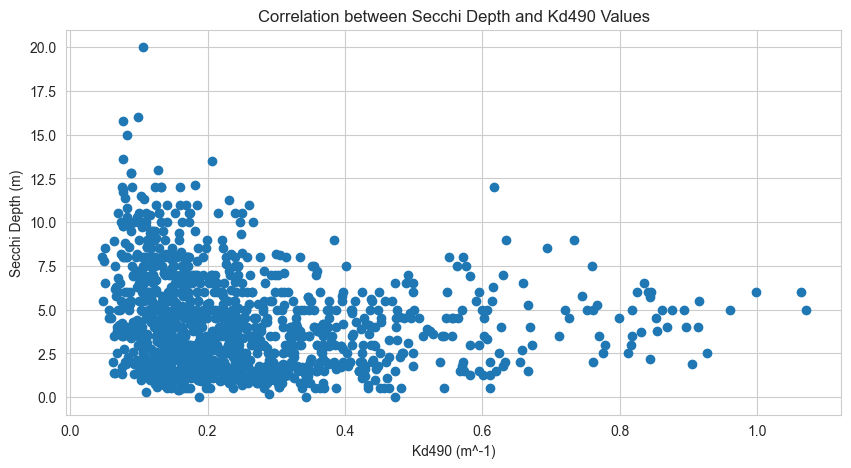

In [26]:
plt.figure(figsize=(10,5))
plt.scatter( secchi_valid['Kd490_match'], secchi_valid['secchi_depth_m'])

plt.xlabel( 'Kd490 (m^-1)')
plt.ylabel( 'Secchi Depth (m)')
plt.title('Correlation between Secchi Depth and Kd490 Values')
plt.savefig('correlation_secchi_kd490_val.png')
plt.show()

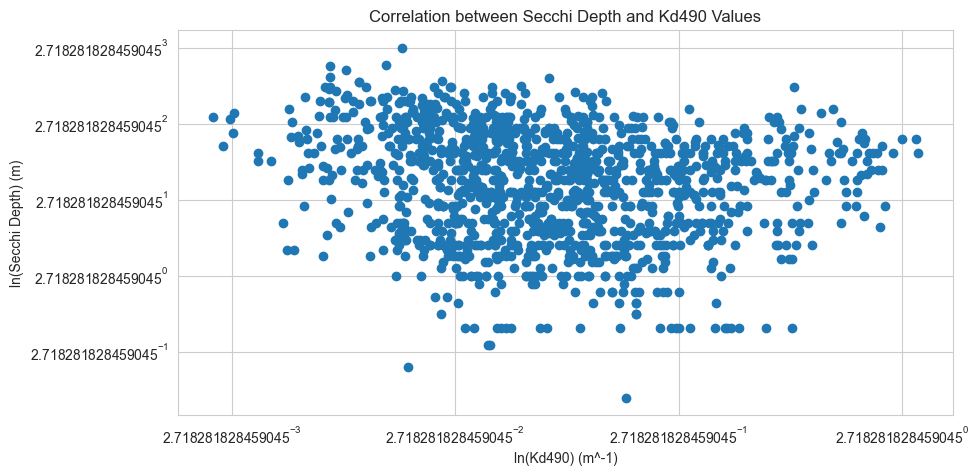

In [27]:
plt.figure(figsize=(10,5))
plt.scatter( secchi_valid['Kd490_match'], secchi_valid['secchi_depth_m'])
plt.xscale('log', base=np.e)
plt.yscale('log', base=np.e)
plt.xlabel( 'ln(Kd490) (m^-1)')
plt.ylabel( 'ln(Secchi Depth) (m)')
plt.title('Correlation between Secchi Depth and Kd490 Values')
plt.savefig('correlation_secchi_kd490_lognatural_val.png')
plt.show()

In [28]:
secchi_valid = secchi_valid.sort_values(by='time', ascending=True)
secchi_valid

,cruise,station,time,latitude,longitude,bottom_depth_m,secchi_depth_m,year,date,Kd490_lat,Kd490_lon,Kd490_date,Kd490_match,lat_diff,lon_diff,dist_meas
2036,4599,0001,2007-02-12 00:00:00+00:00,55.011700,-7.57830,20.0,5.50,2007,2007-02-12 00:00:00+00:00,55.015625,-7.578124,2007-02-12,0.324899,-0.003925,-0.000176,0.003929
5889,4599,0712,2007-02-12 07:12:00+00:00,55.011700,-7.57830,10.0,3.00,2007,2007-02-12 00:00:00+00:00,55.015625,-7.578124,2007-02-12,0.324899,-0.003925,-0.000176,0.003929
12746,4599,1214,2007-02-12 12:14:00+00:00,55.040501,-7.54470,10.0,5.00,2007,2007-02-12 00:00:00+00:00,55.036457,-7.546874,2007-02-12,0.335751,0.004044,0.002174,0.004591
16572,4599,1533,2007-03-01 15:33:00+00:00,52.982201,-6.03250,2.0,1.00,2007,2007-03-01 00:00:00+00:00,52.984375,-6.036457,2007-03-01,0.155271,-0.002174,0.003957,0.004515
11715,4599,1136,2007-05-28 11:36:00+00:00,53.718498,-6.22220,7.0,1.80,2007,2007-05-28 00:00:00+00:00,53.713543,-6.223957,2007-05-28,0.323810,0.004955,0.001757,0.005258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1666,411,91179-4,2023-09-04 13:25:00+00:00,54.304260,-8.57678,6.0,2.50,2023,2023-09-04 00:00:00+00:00,54.307293,-8.578124,2023-09-04,0.498699,-0.003033,0.001344,0.003317
1671,411,91183-3,2023-09-04 14:05:00+00:00,54.327351,-8.61694,2.8,3.25,2023,2023-09-04 00:00:00+00:00,54.328125,-8.619790,2023-09-04,0.476473,-0.000774,0.002851,0.002954
1674,411,91185-3,2023-09-04 14:28:00+00:00,54.313831,-8.65103,17.6,3.25,2023,2023-09-04 00:00:00+00:00,54.317707,-8.651040,2023-09-04,0.464610,-0.003876,0.000010,0.003876
404,411,108966-2,2023-09-12 14:27:00+00:00,53.266590,-9.74137,14.0,10.00,2023,2023-09-12 00:00:00+00:00,53.265625,-9.744791,2023-09-12,0.132509,0.000965,0.003421,0.003554


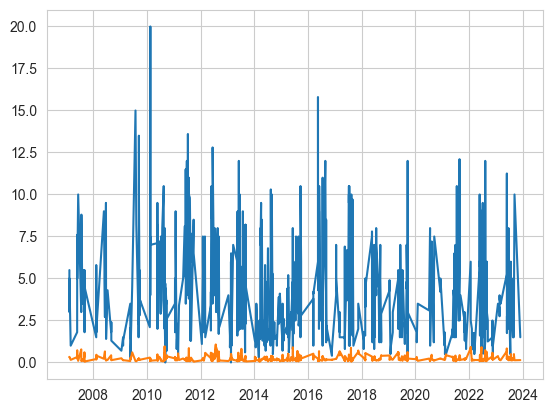

In [29]:
plt.plot(secchi_valid['time'], secchi_valid['secchi_depth_m'])
plt.plot(secchi_valid['time'], secchi_valid['Kd490_match'])
plt.show()

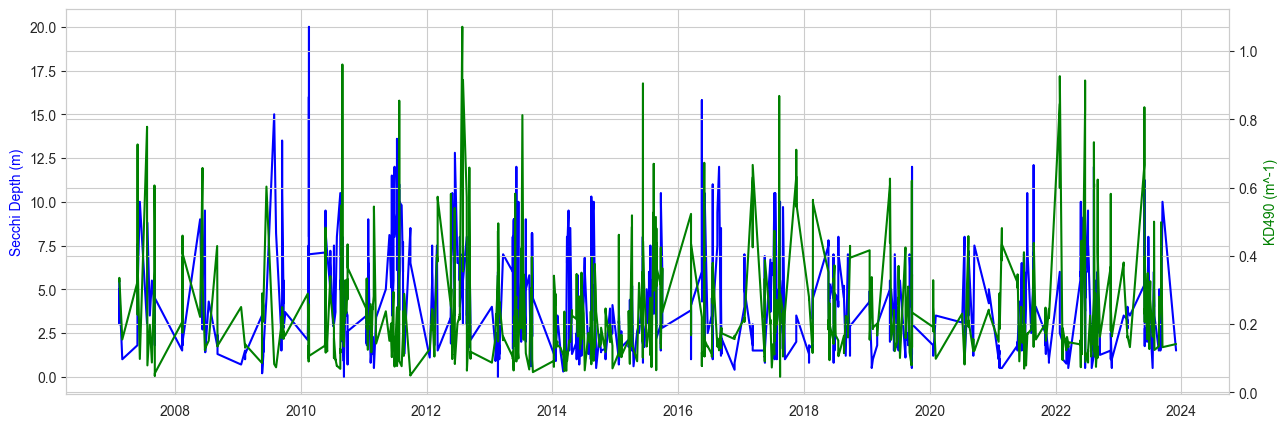

In [30]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(secchi_valid['time'], secchi_valid['secchi_depth_m'], color='blue', label='Secchi Depth')
ax1.set_ylabel('Secchi Depth (m)', color='blue')

ax2 = ax1.twinx()
ax2.plot(secchi_valid['time'], secchi_valid['Kd490_match'], color='green', label='KD490')
ax2.set_ylabel('KD490 (m^-1)', color='green')

plt.show()

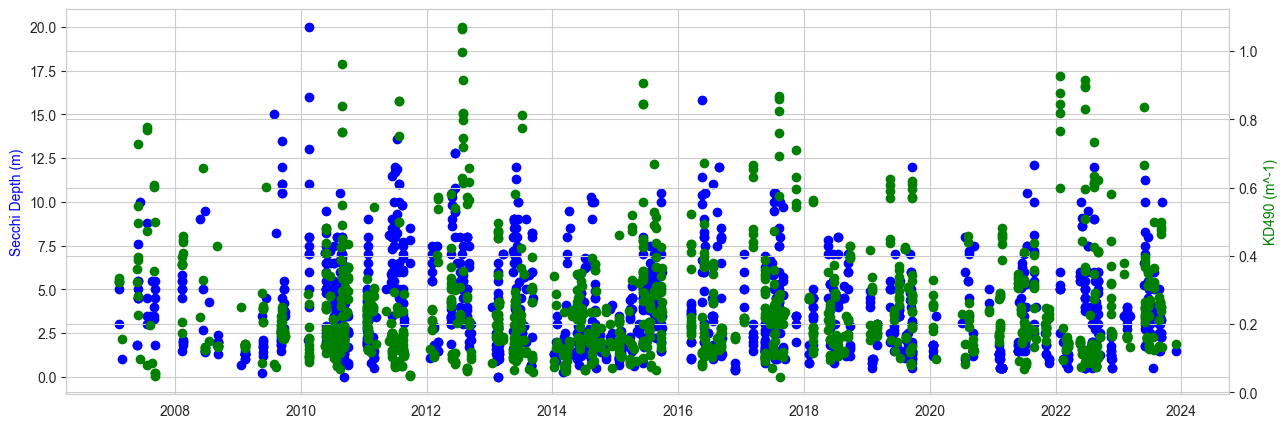

In [32]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.scatter(secchi_valid['time'], secchi_valid['secchi_depth_m'], color='blue', label='Secchi Depth')
ax1.set_ylabel('Secchi Depth (m)', color='blue')

ax2 = ax1.twinx()
ax2.scatter(secchi_valid['time'], secchi_valid['Kd490_match'], color='green', label='KD490')
ax2.set_ylabel('KD490 (m^-1)', color='green')

plt.savefig('secchi_kd490_values_timeline.png')
plt.show()